# NERVE Event Representations

This walkthrough shows how **raw DVS events** (timestamped \(x, y\) with polarity) are turned into **dense, frame-like tensors** suitable for CNNs and fusion pipelines. We load a short slice from `davis/events.hdf5`, then build four representations supported by `nerve.processing.event_representations`: **stacked histogram (shist)**, **VTEI**, **voxel grid**, and **MDES**.


In [1]:
from nerve import config, remote
from nerve.registry import all_sessions
from pathlib import Path

sessions = all_sessions()
smallest = min(sessions, key=lambda s: s.size_bytes)
print(f"Smallest session: {smallest.name}  "
      f"({smallest.size_bytes / 1e9:.2f} GB archive, split={smallest.split})")

session_dir = Path(remote.download_session(smallest.name))
print(f"Session directory: {session_dir}")


Smallest session: 2023-10-26_15-37-59  (0.40 GB archive, split=train)
  Session already exists: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59
Session directory: /gpfs/home5/omansour/.nerve/data/2023-10-26_15-37-59


## Loading raw events from HDF5

NERVE DAVIS captures store events under `davis/events.hdf5`. The compound dataset `events` exposes fields such as `t` (time, typically microseconds), `x`, `y`, and `p` (polarity). File and dataset attributes often include `width`, `height`, and `total_events`.


In [2]:
import h5py
import numpy as np

ev_path = session_dir / "davis" / "events.hdf5"
if not ev_path.is_file():
    raise FileNotFoundError(f"Missing {ev_path} -- run the download cell first.")

with h5py.File(ev_path, "r") as f:
    ev = f["events"]
    width = int(ev.attrs.get("width", f.attrs.get("width", 346)))
    height = int(ev.attrs.get("height", f.attrs.get("height", 260)))
    t_all = ev["t"][:]

    # Pick a 50 ms window from the densest 1-second bin
    bin_edges = np.arange(t_all[0], t_all[-1], 1_000_000)
    counts, _ = np.histogram(t_all, bins=bin_edges)
    best_start = int(bin_edges[np.argmax(counts)])

    lo = np.searchsorted(t_all, best_start)
    hi = np.searchsorted(t_all, best_start + 50_000)
    events = ev[lo:hi]

print(f"Window: {best_start} .. {best_start + 50_000} us  "
      f"({len(events):,} events, sensor: {width}×{height})")


Window: 254192803 .. 254242803 us  (13,267 events, sensor: 346×260)


## Stacked histogram (shist)

The **stacked histogram** bins events in time and separates polarities. The tensor has shape **(2·bins, H, W)** -- the first `bins` slices accumulate polarity 0, the next `bins` polarity 1. For a quick **two-channel** view, sum over the temporal bins separately for each polarity.


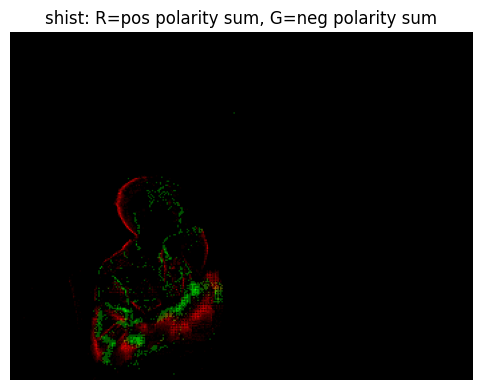

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from nerve.processing.event_representations import process_events

bins = 5
sh = process_events(events, "shist", bins, height, width)
# sh: (2*bins, H, W) -- collapse time per polarity
pos = sh[:bins].sum(axis=0).astype(np.float32)
neg = sh[bins : 2 * bins].sum(axis=0).astype(np.float32)
# normalize for display
def norm01(a):
    a = a - a.min()
    return a / (a.max() + 1e-6)

rgb = np.dstack([norm01(pos), norm01(neg), np.zeros_like(pos)])
plt.figure(figsize=(6, 4))
plt.imshow(rgb)
plt.title("shist: R=pos polarity sum, G=neg polarity sum")
plt.axis("off")
plt.tight_layout()
plt.show()


## VTEI (Volume of Ternary Event Images)

**VTEI** divides the time window into uniform bins and stores the most recent ternary polarity (+1/−1/0) at each spatial location per bin; the output has shape **(bins, H, W)**. The API is `process_events(events, method, bins, height, width)`.


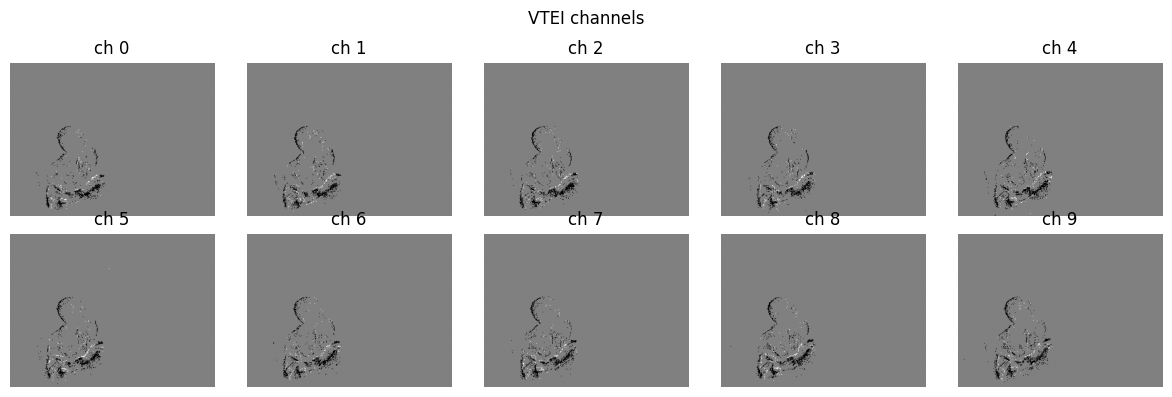

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from nerve.processing.event_representations import process_events

bins = 10
result = process_events(events, "vtei", bins, height, width)
fig, axes = plt.subplots(2, (bins + 1) // 2, figsize=(12, 4))
axes = np.atleast_2d(axes).ravel()
for i in range(bins):
    axes[i].imshow(result[i], cmap="gray", vmin=result.min(), vmax=result.max())
    axes[i].set_title(f"ch {i}")
    axes[i].axis("off")
for j in range(bins, len(axes)):
    axes[j].axis("off")
plt.suptitle("VTEI channels")
plt.tight_layout()
plt.show()


## Voxel grid

The **voxel grid** applies bilinear weighting along time; output shape **(2·bins, H, W)** (both polarities and time bins).


Voxel grid shape: (10, 260, 346)  (channels 0–4: polarity 0, 5–9: polarity 1)


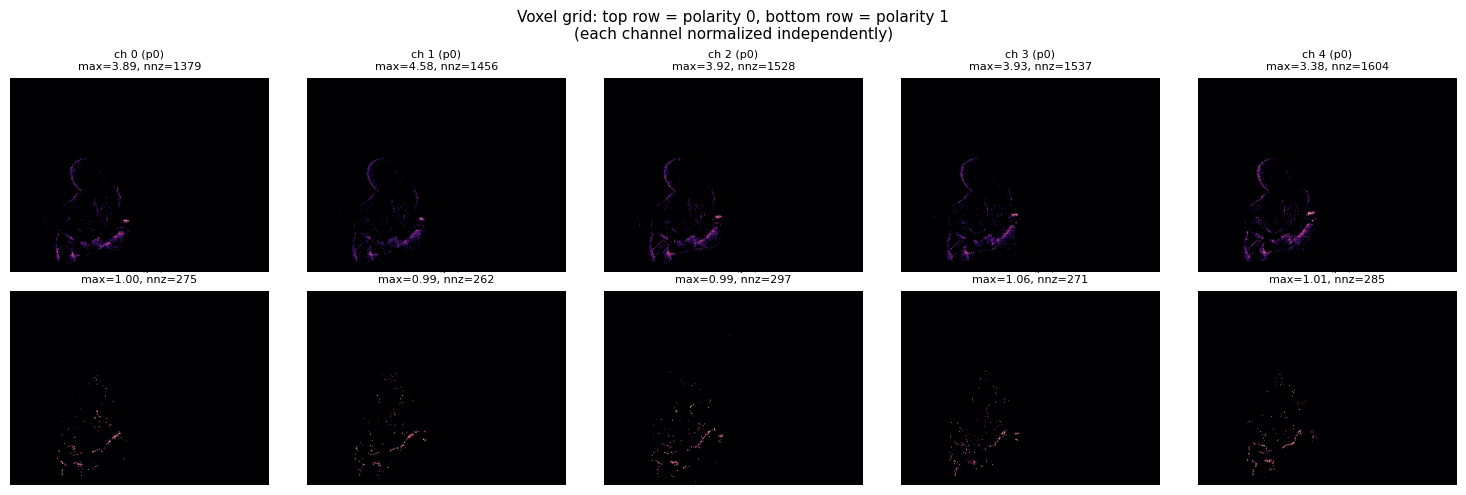

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from nerve.processing.event_representations import process_events

bins = 5
vg = process_events(events, "voxel_grid", bins, height, width)
n_ch = vg.shape[0]
print(f"Voxel grid shape: {vg.shape}  (channels 0-{bins-1}: polarity 0, "
      f"{bins}-{n_ch-1}: polarity 1)")

fig, axes = plt.subplots(2, bins, figsize=(3 * bins, 5))
for i in range(n_ch):
    row, col = divmod(i, bins)
    ch = vg[i]
    im = axes[row, col].imshow(ch, cmap="magma", vmin=0, vmax=ch.max() or 1)
    axes[row, col].set_title(f"ch {i} (p{row})\nmax={ch.max():.2f}, nnz={np.count_nonzero(ch)}",
                             fontsize=8)
    axes[row, col].axis("off")
plt.suptitle("Voxel grid: top row = polarity 0, bottom row = polarity 1\n"
             "(each channel normalized independently)", fontsize=11)
plt.tight_layout()
plt.show()


## MDES

**MDES** (Mixed Density Event Stacks) builds a multi-bin surface with signed polarity; shape **(bins, H, W)**.


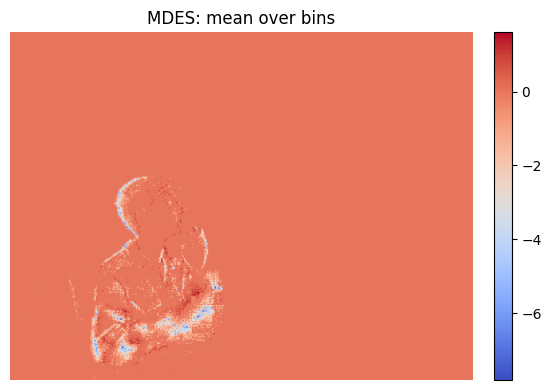

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from nerve.processing.event_representations import process_events

bins = 5
mdes = process_events(events, "mdes", bins, height, width)
plt.figure(figsize=(6, 4))
plt.imshow(mdes.mean(axis=0), cmap="coolwarm")
plt.title("MDES: mean over bins")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Side-by-side comparison

The four methods emphasize **temporal integration** (shist, voxel grid) vs **recency** structure (MDES uses log-time binning; VTEI stores only the last polarity per uniform bin). Below: a 2×2 panel of comparable grayscale summaries.


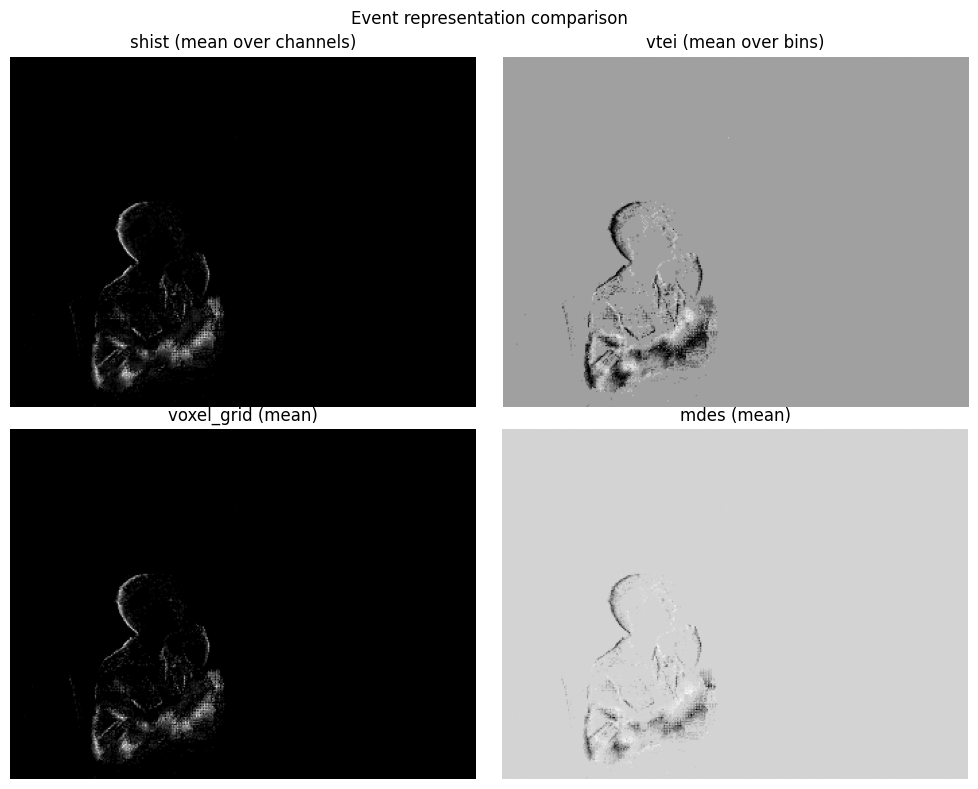

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from nerve.processing.event_representations import process_events

bins = 5
sh = process_events(events, "shist", bins, height, width)
vt = process_events(events, "vtei", bins, height, width)
vg = process_events(events, "voxel_grid", bins, height, width)
md = process_events(events, "mdes", bins, height, width)

def gray(a):
    a = np.asarray(a, dtype=np.float32)
    if a.ndim == 3:
        a = a.mean(axis=0)
    a = (a - a.min()) / (a.max() - a.min() + 1e-6)
    return a

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].imshow(gray(sh), cmap="gray")
ax[0, 0].set_title("shist (mean over channels)")
ax[0, 1].imshow(gray(vt), cmap="gray")
ax[0, 1].set_title("vtei (mean over bins)")
ax[1, 0].imshow(gray(vg), cmap="gray")
ax[1, 0].set_title("voxel_grid (mean)")
ax[1, 1].imshow(gray(md), cmap="gray")
ax[1, 1].set_title("mdes (mean)")
for a in ax.ravel():
    a.axis("off")
plt.suptitle("Event representation comparison")
plt.tight_layout()
plt.show()
